
# MuPT &harr; AutoREACTER bridge: SMILES &rarr; MuPT &rarr; SMILES dict &rarr; `input.json` / YAML

This notebook demonstrates the **Phase 1** hand-off between MuPT and AutoREACTER:

```
hand-authored SMILES  ---->  MuPT Primitive  ---->  {name: smiles} dict
                                                            |
                                                            v
                                        hand-authored recipe (YAML: counts/ratio,
                                        temperature, density, force_field)
                                                            |
                                                            v
                                              AutoREACTER-ready input.json
```

Two source paths for monomer SMILES both converge on the same `{name: smiles}` dict:

- **Path A** — SMILES typed directly into a YAML `monomers:` block (no MuPT involved).
- **Path B** — SMILES round-tripped *through* a MuPT `Primitive` (`primitive_from_rdkit` &rarr;
  `primitive_to_rdkit` &rarr; `Chem.MolToSmiles`), for monomers that originate as MuPT objects.

Every function used from `mupt` and `AutoREACTER` below is a real, existing function in each
package — nothing here is invented or stubbed. Where possible we validate output against
AutoREACTER's own `InputParser`, so the generated `input.json` is proven to parse, not just
"shaped right."


## 0. Setup

In [1]:
%pip install mupt

Note: you may need to restart the kernel to use updated packages.


In [1]:

from rdkit import Chem

from mupt.interfaces.rdkit.importers import primitive_from_rdkit
from mupt.interfaces.rdkit.exporters import primitive_to_rdkit

import json
import yaml  # PyYAML
from pathlib import Path

OUT_DIR = Path("bridge_outputs")
OUT_DIR.mkdir(exist_ok=True)



## 1. Start from SMILES

These are the two monomers from AutoREACTER's own `examples/polyamide_count_mode_basic.json`
(trimesoyl chloride + m-phenylenediamine), used here so the final `input.json` can be checked
against a known-good AutoREACTER example.


In [2]:

monomer_smiles_hand_authored = {
    "trimesoyl_chloride": "ClC(=O)c1cc(cc(c1)C(Cl)=O)C(Cl)=O",
    "m_phenylenediamine": "C1=CC(=CC(=C1)N)N",
}
monomer_smiles_hand_authored


{'trimesoyl_chloride': 'ClC(=O)c1cc(cc(c1)C(Cl)=O)C(Cl)=O',
 'm_phenylenediamine': 'C1=CC(=CC(=C1)N)N'}


## 2. SMILES &rarr; MuPT `Primitive`

`primitive_from_rdkit` is MuPT's existing RDKit importer (`mupt.interfaces.rdkit.importers`).
It builds one atom-leaf child `Primitive` per atom and wires up bonds as internal `Connector`
pairs. We add explicit hydrogens first so the `Primitive` hierarchy is a genuine all-atom
representation (matching what `primitive_from_rdkit` expects for atomic leaves).


In [3]:

def smiles_to_primitive(name: str, smiles: str):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"RDKit could not parse SMILES for {name!r}: {smiles!r}")
    mol = Chem.AddHs(mol)
    return primitive_from_rdkit(mol, label=name)


monomer_primitives = {
    name: smiles_to_primitive(name, smiles)
    for name, smiles in monomer_smiles_hand_authored.items()
}

for name, prim in monomer_primitives.items():
    print(f"{name}: {len(prim.children_by_handle)} atoms (incl. H), role={prim.role}")


trimesoyl_chloride: 18 atoms (incl. H), role=PrimitiveRole.UNASSIGNED
m_phenylenediamine: 16 atoms (incl. H), role=PrimitiveRole.UNASSIGNED



## 3. MuPT `Primitive` &rarr; `{name: smiles}` dict  (Path B)

This is the direction that matters for the bridge: **what MuPT hands back out**. We use
MuPT's existing exporter, `primitive_to_rdkit` (`mupt.interfaces.rdkit.exporters`), then let
RDKit canonicalize. Hydrogens are stripped before canonicalization so the SMILES matches the
plain (implicit-H) form AutoREACTER's own examples use.

`primitive_to_rdkit` emits a `DeprecationWarning` suggesting the role-aware
`primitive_to_rdkit_mols()` exporter instead &mdash; that one requires SAAMR
role-annotated hierarchies (segments/residues), which a bare monomer prototype doesn't have.
For flat, monomer-level primitives like these, `primitive_to_rdkit` is the correct function;
the warning is expected and harmless here.


In [4]:

import warnings


def primitive_to_smiles(prim) -> str:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", DeprecationWarning)
        mol = primitive_to_rdkit(prim)
    mol = Chem.RemoveHs(mol)
    return Chem.MolToSmiles(mol)


monomer_smiles_from_mupt = {
    name: primitive_to_smiles(prim) for name, prim in monomer_primitives.items()
}
monomer_smiles_from_mupt


{'trimesoyl_chloride': 'O=C(Cl)c1cc(C(=O)Cl)cc(C(=O)Cl)c1',
 'm_phenylenediamine': 'Nc1cccc(N)c1'}

### Sanity check: did the round trip preserve the chemistry?

In [5]:

for name in monomer_smiles_hand_authored:
    original_canon = Chem.CanonSmiles(monomer_smiles_hand_authored[name])
    roundtrip_canon = Chem.CanonSmiles(monomer_smiles_from_mupt[name])
    status = "OK" if original_canon == roundtrip_canon else "MISMATCH"
    print(f"{name:>22}: {status}  ({roundtrip_canon})")


    trimesoyl_chloride: OK  (O=C(Cl)c1cc(C(=O)Cl)cc(C(=O)Cl)c1)
    m_phenylenediamine: OK  (Nc1cccc(N)c1)



## 4. The hand-authored recipe (YAML)

Per what we settled earlier: **temperature, density, monomer counts/ratios, and force_field
are always hand-authored** &mdash; there's no derivation for these, they're genuine
experimental choices. This mirrors the schema MuPT's own `mupt/reactions` config-support
discussion (issue #84) is converging on, using AutoREACTER's *actual* top-level key
(`simulations`, not `systems` &mdash; verified against `input_parser.py` and AutoREACTER's own
working examples).

Note the `monomers:` list here has **no `smiles:` key** &mdash; this is the Path B case, where
SMILES gets filled in from the MuPT-sourced dict from Section 3, matched by `name`.


In [6]:

recipe_yaml_text = '''
simulation_name: Polyamide_Count_Mode_Basic
force_field: PCFF

simulations:
  - tag: 10k_300K
    temperature: 300
    density: 0.8
    monomer_counts:
      trimesoyl_chloride: 220
      m_phenylenediamine: 330

  - tag: 100k_400K
    temperature: 400
    density: 0.8
    monomer_counts:
      trimesoyl_chloride: 2200
      m_phenylenediamine: 3300

monomers:
  - name: trimesoyl_chloride
  - name: m_phenylenediamine
'''

recipe_yaml_path = OUT_DIR / "recipe.yaml"
recipe_yaml_path.write_text(recipe_yaml_text.strip() + "\n")

recipe = yaml.safe_load(recipe_yaml_text)
recipe


{'simulation_name': 'Polyamide_Count_Mode_Basic',
 'force_field': 'PCFF',
 'simulations': [{'tag': '10k_300K',
   'temperature': 300,
   'density': 0.8,
   'monomer_counts': {'trimesoyl_chloride': 220, 'm_phenylenediamine': 330}},
  {'tag': '100k_400K',
   'temperature': 400,
   'density': 0.8,
   'monomer_counts': {'trimesoyl_chloride': 2200,
    'm_phenylenediamine': 3300}}],
 'monomers': [{'name': 'trimesoyl_chloride'}, {'name': 'm_phenylenediamine'}]}


## 5. Merge (YAML recipe) + (SMILES dict) &rarr; `input.json`

One converter function, used regardless of whether the SMILES came from Path A (hand-typed,
already present in the YAML's `monomers:` entries) or Path B (the MuPT-sourced dict from
Section 3). If a `monomers:` entry already has a `smiles` key, it's left alone; otherwise it's
filled in by name from `smiles_by_name`.


In [7]:

def build_input_json(recipe: dict, smiles_by_name: dict[str, str]) -> dict:
    '''Merge a hand-authored recipe (YAML-shaped dict) with a {name: smiles} dict
    into an AutoREACTER-ready input.json dict.'''
    monomers_out = []
    for entry in recipe["monomers"]:
        name = entry["name"]
        smiles = entry.get("smiles")
        if smiles is None:
            try:
                smiles = smiles_by_name[name]
            except KeyError as exc:
                raise ValueError(
                    f"Monomer {name!r} has no 'smiles' in the recipe and none was "
                    "supplied in smiles_by_name."
                ) from exc
        monomers_out.append({"name": name, "smiles": smiles})

    return {
        "simulation_name": recipe["simulation_name"],
        "force_field": recipe["force_field"],
        "simulations": recipe["simulations"],
        "monomers": monomers_out,
    }


input_json_dict = build_input_json(recipe, monomer_smiles_from_mupt)
input_json_dict


{'simulation_name': 'Polyamide_Count_Mode_Basic',
 'force_field': 'PCFF',
 'simulations': [{'tag': '10k_300K',
   'temperature': 300,
   'density': 0.8,
   'monomer_counts': {'trimesoyl_chloride': 220, 'm_phenylenediamine': 330}},
  {'tag': '100k_400K',
   'temperature': 400,
   'density': 0.8,
   'monomer_counts': {'trimesoyl_chloride': 2200,
    'm_phenylenediamine': 3300}}],
 'monomers': [{'name': 'trimesoyl_chloride',
   'smiles': 'O=C(Cl)c1cc(C(=O)Cl)cc(C(=O)Cl)c1'},
  {'name': 'm_phenylenediamine', 'smiles': 'Nc1cccc(N)c1'}]}

## 6. Write `input.json`

In [8]:

input_json_path = OUT_DIR / "input.json"
input_json_path.write_text(json.dumps(input_json_dict, indent=2) + "\n")
print(input_json_path.read_text())


{
  "simulation_name": "Polyamide_Count_Mode_Basic",
  "force_field": "PCFF",
  "simulations": [
    {
      "tag": "10k_300K",
      "temperature": 300,
      "density": 0.8,
      "monomer_counts": {
        "trimesoyl_chloride": 220,
        "m_phenylenediamine": 330
      }
    },
    {
      "tag": "100k_400K",
      "temperature": 400,
      "density": 0.8,
      "monomer_counts": {
        "trimesoyl_chloride": 2200,
        "m_phenylenediamine": 3300
      }
    }
  ],
  "monomers": [
    {
      "name": "trimesoyl_chloride",
      "smiles": "O=C(Cl)c1cc(C(=O)Cl)cc(C(=O)Cl)c1"
    },
    {
      "name": "m_phenylenediamine",
      "smiles": "Nc1cccc(N)c1"
    }
  ]
}




## 7. Validate against AutoREACTER's real `InputParser`

This is the actual proof the generated `input.json` is usable, not just correctly-shaped by
eye: it's run through AutoREACTER's own `InputParser.validate_inputs`, the exact function
`arx.run("input.json")` calls internally.

Set `AUTOREACTER_PATH` below to wherever your local AutoREACTER checkout / install lives.


In [9]:
%pip install AutoREACTER

  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 4.9 MB/s  0:00:00 eta 0:00:01m
Using cached setuptools-84.0.0-py3-none-any.whl (818 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [AutoREACTER] [AutoREACTER]
Note: you may need to restart the kernel to use updated packages.


In [16]:

import sys

import AutoREACTER as ARX
from AutoREACTER.input_parser import InputParser
from AutoREACTER.session import Session

parser = InputParser()
simulation_setup = parser.validate_inputs(input_json_dict)
session = Session(inputs = simulation_setup,
                  staging_dir = "/mnt/c/Users/janit/Documents/mupt",
                  output_dir = "/mnt/c/Users/janit/Documents/mupt/output",
                  images_dir = "/mnt/c/Users/janit/Documents/mupt/images"
                  )
print("Parsed OK:", type(simulation_setup).__name__)
print("simulation_name:", simulation_setup.simulation_name)
print("force_field:", simulation_setup.force_field)
print("monomers:", [m.name for m in simulation_setup.monomers])
print("monomer SMILES (as parsed by AutoREACTER):",
      {m.name: m.smiles for m in simulation_setup.monomers})
session

Parsed OK: SimulationSetup
simulation_name: Polyamide_Count_Mode_Basic
force_field: PCFF
monomers: ['trimesoyl_chloride', 'm_phenylenediamine']
monomer SMILES (as parsed by AutoREACTER): {'trimesoyl_chloride': 'O=C(Cl)c1cc(C(=O)Cl)cc(C(=O)Cl)c1', 'm_phenylenediamine': 'Nc1cccc(N)c1'}


Session(inputs=SimulationSetup(simulation_name='Polyamide_Count_Mode_Basic', temperature=[300.0, 400.0], density=[0.8, 0.8], force_field='PCFF', monomers=[MonomerEntry(id=1, data_id='data_1', name='trimesoyl_chloride', smiles='O=C(Cl)c1cc(C(=O)Cl)cc(C(=O)Cl)c1', count={'10k_300K': 220, '100k_400K': 2200}, ratio=None, rdkit_mol=<rdkit.Chem.rdchem.Mol object at 0x7cbb2a8f7220>, molecule_3Dmol_path=None, lmp_molecule_file=None, num_atoms=18, molecular_weight=265.479, status=True), MonomerEntry(id=2, data_id='data_2', name='m_phenylenediamine', smiles='Nc1cccc(N)c1', count={'10k_300K': 330, '100k_400K': 3300}, ratio=None, rdkit_mol=<rdkit.Chem.rdchem.Mol object at 0x7cbb2a8f7530>, molecule_3Dmol_path=None, lmp_molecule_file=None, num_atoms=16, molecular_weight=108.144, status=True)], input_json={'simulation_name': 'Polyamide_Count_Mode_Basic', 'force_field': 'PCFF', 'simulations': [{'tag': '10k_300K', 'temperature': 300.0, 'density': 0.8, 'monomer_counts': {'trimesoyl_chloride': 220, 'm_ph

In [18]:
from AutoREACTER.detectors.functional_groups_detector import FunctionalGroupsDetector
FunctionalGroupsDetector().functional_groups_detector(session)

O=C(Cl)c1cc(C(=O)Cl)cc(C(=O)Cl)c1 has functionality: di_carboxylic_acid_halide
Nc1cccc(N)c1 has functionality: primary_amine
Nc1cccc(N)c1 has functionality: di_amine
Nc1cccc(N)c1 has functionality: di_primary_amine


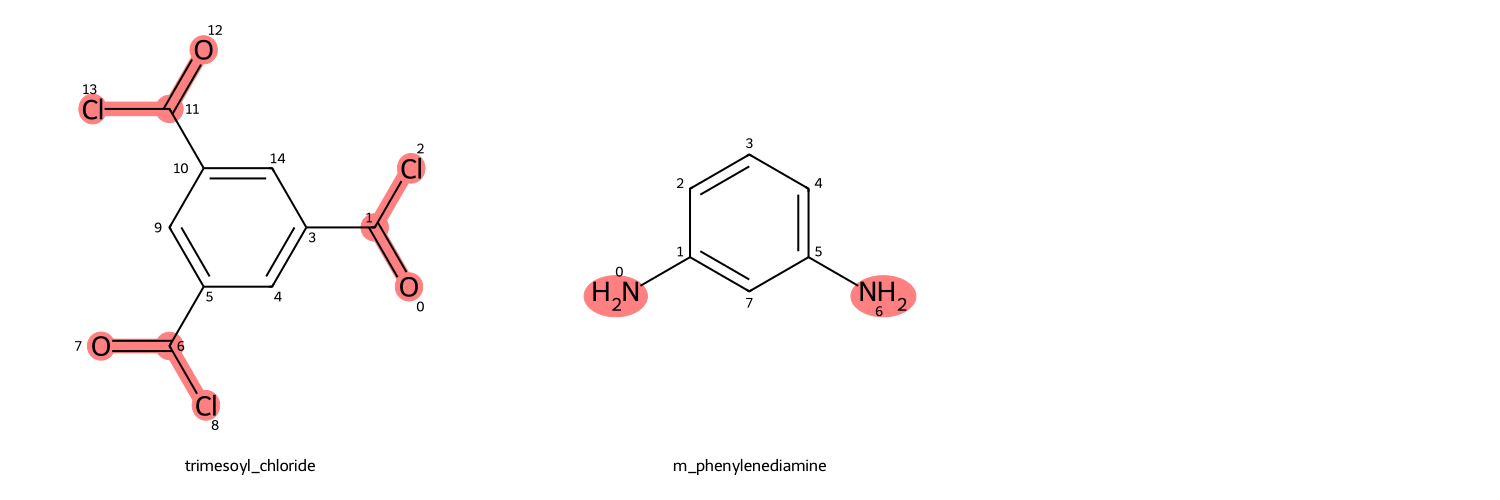

In [20]:
FunctionalGroupsDetector().functional_group_highlighted_molecules_image_grid(session)

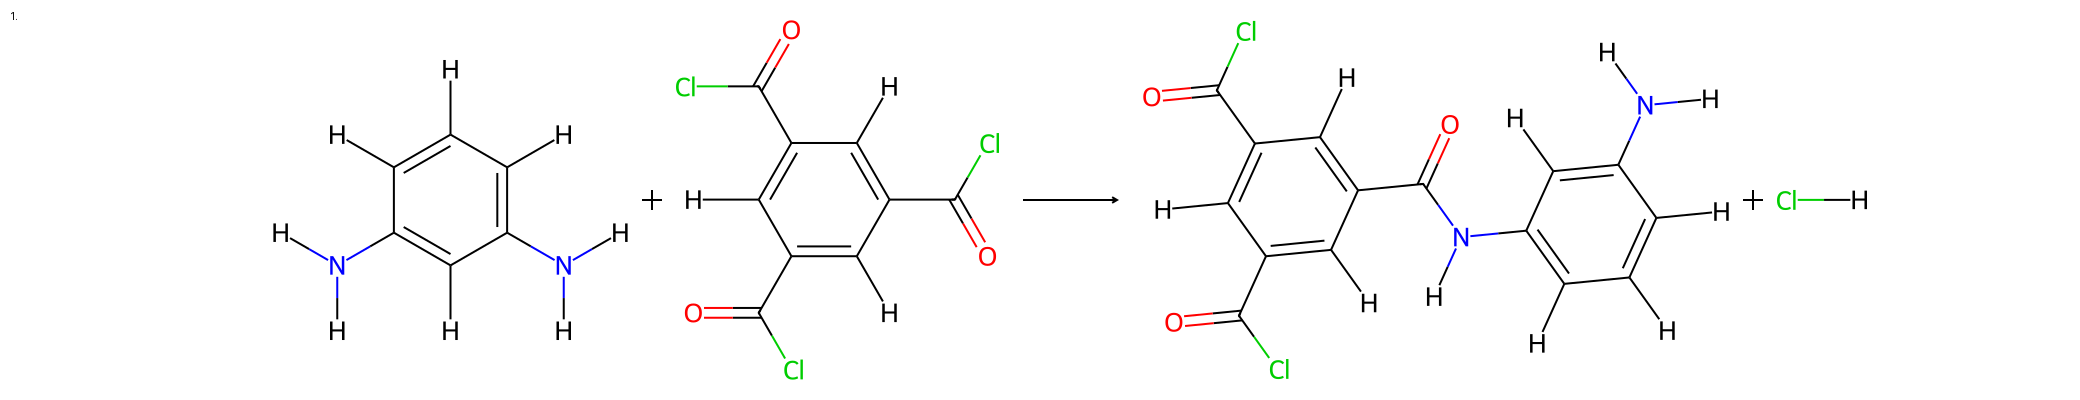

In [22]:
from AutoREACTER.detectors.reaction_detector import ReactionDetector
ReactionDetector().reaction_detector(session)
ReactionDetector().available_reaction_image_grid(session)

In [ ]:
from AutoREACTER.detectors.non_monomer_detector import NonMonomerDetector
NonMonomerDetector().non_monomer_detector(session)


In [27]:
ARX.prepare_reactions()

RuntimeError: No active session. Please run `arx.run('your_file.json')` first.